In [1]:
from torch.utils.data import DataLoader
from functools import partial
from torch.utils.data import Dataset
import json,os,requests,tiktoken, torch
from importlib.metadata import version
import pandas as pd
from  previous_chapters import *
from gpt_download import download_and_load_gpt2

pkgs = [
    "numpy",       # PyTorch & TensorFlow dependency
    "matplotlib",  # Plotting library
    "tiktoken",    # Tokenizer
    "torch",       # Deep learning library
    "tqdm",        # Progress bar
    "tensorflow",  # For OpenAI's pretrained weights
]
for p in pkgs:
    print(f"{p} version: {version(p)}")


os.chdir(r"C:\LLM\Python3.10\Code")


numpy version: 2.2.6
matplotlib version: 3.10.9
tiktoken version: 0.13.0
torch version: 2.13.0
tqdm version: 4.70.0
tensorflow version: 2.21.0


&nbsp;
## Preparing a dataset for supervised instruction finetuning

In [2]:

file_path = "QAJson4.json"
with open(file_path, "r", encoding="utf-8") as file:
    data = json.load(file)
print("Number of entries:", len(data))

Number of entries: 100


- Each item in the `data` list we loaded from the JSON file above is a dictionary in the following form

In [3]:
print("Example entry:\n", data[50])

Example entry:
 {'Problem': "The customer is experiencing inconsistencies in the document numbering sequence for Outgoing Bank Transfers, where document numbers are not being generated in an expected sequential order. This behavior is causing concerns regarding transaction traceability, audit compliance, and reconciliation processes. The customer is unable to confirm whether the observed behavior is functioning as designed or indicates an underlying system issue. The explanation provided in the previous incident regarding the internal logic and standard behavior does not adequately address the customer's concern about the non-sequential numbering pattern.", 'solution provided': "The issue is a standard system behavior of the MASKED_ORG Business ByDesign system, where the payment document ID is generated based on a combination of parameters such as Company Code, Payment Method, Business Partner, Bank Account, and [PERSON NAME]. This logic is part of the standard system design defined by

- Note that the `'input'` field can be empty:

In [4]:
print("Another example entry:\n", data[99])

Another example entry:
 {'Problem': "The customer is experiencing recurring Data Flow Verification (DFV) results (IDs 8647 and 8609) that are not being automatically closed despite the automatic closure setting being enabled. Application logs show 'DFV result is not complete' and 'A technical error occurred during verification.' The customer previously encountered the same behavior and manually closed the results, but the issue has reoccurred. Relevant KBAs and similar cases were reviewed with no applicable solution.", 'solution provided': "The development team confirmed that there is currently no active issue with the DFV process. All subsequent DFV executions after 04.07.2026 have completed successfully and have been closed automatically. The historical DFV results 8647 and 8609 remain in an open status but can be manually changed to the 'Closed' status as no discrepancies are present. The development team also observed that creating a new DFV run manually is currently not possible. 

- Format the input that we will pass as input to the LLM

In [5]:
def format_input(entry):
    instruction_text = (
        f"Below is an problem faced while using SAP BYD product. "
        f"Provide the solution for the problem."
        #f"\n\n### Problem:\n{entry['Problem']}"
    )

    input_text = f"\n\n### Problem:\n{entry['Problem']}" if entry["Problem"] else ""

    return instruction_text + input_text

- A formatted response with input field looks like as shown below

In [6]:
model_input = format_input(data[50])
desired_response = f"\n\n### Solution provided:\n{data[50]['solution provided']}"
print("Model input:\n", model_input)
print("Desired response:\n", desired_response)
#print(model_input + desired_response)

Model input:
 Below is an problem faced while using SAP BYD product. Provide the solution for the problem.

### Problem:
The customer is experiencing inconsistencies in the document numbering sequence for Outgoing Bank Transfers, where document numbers are not being generated in an expected sequential order. This behavior is causing concerns regarding transaction traceability, audit compliance, and reconciliation processes. The customer is unable to confirm whether the observed behavior is functioning as designed or indicates an underlying system issue. The explanation provided in the previous incident regarding the internal logic and standard behavior does not adequately address the customer's concern about the non-sequential numbering pattern.
Desired response:
 

### Solution provided:
The issue is a standard system behavior of the MASKED_ORG Business ByDesign system, where the payment document ID is generated based on a combination of parameters such as Company Code, Payment Method

- Below is a formatted response without an input field

In [7]:
model_input = format_input(data[99])
desired_response = f"\n\n### Solution provided:\n{data[99]['solution provided']}"

print(model_input + desired_response)

Below is an problem faced while using SAP BYD product. Provide the solution for the problem.

### Problem:
The customer is experiencing recurring Data Flow Verification (DFV) results (IDs 8647 and 8609) that are not being automatically closed despite the automatic closure setting being enabled. Application logs show 'DFV result is not complete' and 'A technical error occurred during verification.' The customer previously encountered the same behavior and manually closed the results, but the issue has reoccurred. Relevant KBAs and similar cases were reviewed with no applicable solution.

### Solution provided:
The development team confirmed that there is currently no active issue with the DFV process. All subsequent DFV executions after 04.07.2026 have completed successfully and have been closed automatically. The historical DFV results 8647 and 8609 remain in an open status but can be manually changed to the 'Closed' status as no discrepancies are present. The development team also obs

- We divide the dataset into a training, validation, and test set

In [8]:
train_portion = int(len(data) * 0.85)  # 85% for training
test_portion = int(len(data) * 0.1)    # 10% for testing
val_portion = len(data) - train_portion - test_portion  # Remaining 5% for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [9]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))
print("Test",test_data)

Training set length: 85
Validation set length: 5
Test set length: 10
Test [{'Problem': 'When attempting to adjust the quantity of in-transit stock to zero, the customer encounters a technical error indicating that certain serial numbers for a specific product exist more than once. This issue seriously affects business operations as urgent tasks cannot be executed.', 'solution provided': 'The MASKED_ORG team has identified the root cause of the issue and is working on a resolution. They have requested a clone tenant for further analysis and testing to safely investigate and validate potential solutions without impacting the productive environment. The customer has been asked to provide test data and detailed steps to reproduce the issue in their test system. The case remains open, and updates are expected within specified timeframes.'}, {'Problem': 'The issue is that the CC and BCC email addresses are not being retained in the Output Settings pop-up for Quotation (RFQ) in the Business B

&nbsp;
## Organizing data into training batches
- We tackle this dataset batching in several steps
- We implement an `InstructionDataset` class that pre-tokenizes all inputs in the dataset

In [ ]:
class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        # Pre-tokenize texts
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            #print("in instruction dataset\n",entry)
            print("in instruction dataset\n",entry['solution provided'])
            response_text = f"\n\n### Solution provided:\n{entry['solution provided']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

- We multiple training examples in a batch to accelerate training; this requires padding all inputs to a similar length
- We use the `<|endoftext|>` token as a padding token

In [ ]:

tokenizer = tiktoken.get_encoding("gpt2")

print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]



  - Custom collate function pads the training examples in each batch to have the same length (but different batches can have different lengths)

In [ ]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # Find the longest sequence in the batch
    # and increase the max length by +1, which will add one extra
    # padding token below
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst = []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to batch_max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        # Via padded[:-1], we remove the extra padded token
        # that has been added via the +1 setting in batch_max_length
        # (the extra padding token will be relevant in later codes)
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)

    # Convert list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

In [ ]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


- As in pretraining an LLM, the targets are the inputs shifted by 1 position to the right, so the LLM learns to predict the next token

In [ ]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [ ]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


- Introduce an `ignore_index` value to replace all padding token IDs with a new value; the purpose of this `ignore_index` is that we can ignore padding values in the loss function 
- We replace the token IDs corresponding to `50256` with `-100`
- we introduce the `allowed_max_length` in case we want to limit the length of the samples; this will be useful to work withdatasets that are longer than the 1024 token context size supported by the GPT-2 model

In [ ]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs and targets
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets

        # New: Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # New: Optionally truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs and targets to tensors and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [ ]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


- Let's see what this replacement by -100 accomplishes
- For illustration purposes, let's assume we have a small classification task with 2 class labels, 0 and 1
- If we have the following logits values (outputs of the last layer of the model), we calculate the following loss

In [ ]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],  # 1st training example
     [-0.5, 1.5]]  # 2nd training example
)
targets_1 = torch.tensor([0, 1])


loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


- Now, adding one more training example will, as expected, influence the loss

In [ ]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


- Let's see what happens if we replace the class label of one of the examples with -100

In [ ]:
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


- As we can see, the resulting loss on these 3 training examples is the same as the loss we calculated from the 2 training examples, which means that the cross-entropy loss function ignored the training example with the -100 label
- By default, PyTorch has the `cross_entropy(..., ignore_index=-100)` setting to ignore examples corresponding to the label -100
- Using this -100 `ignore_index`, we can ignore the additional end-of-text (padding) tokens in the batches that we used to pad the training examples to equal length
- However, we don't want to ignore the first instance of the end-of-text (padding) token (50256) because it can help signal to the LLM when the response is complete

&nbsp;
## Creating data loaders for an instruction dataset

- In this section, we use the `InstructionDataset` class and `custom_collate_fn` function to instantiate the training, validation, and test data loaders

- Another additional detail of the previous `custom_collate_fn` function is that we now directly move the data to the target device (e.g., GPU) instead of doing it in the main training loop, which improves efficiency because it can be carried out as a background process when we use the `custom_collate_fn` as part of the data loader
- Using the `partial` function from Python's `functools` standard library, we create a new function with the `device` argument of the original function pre-filled

In [21]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: cpu


In [22]:

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

- Next, we instantiate the data loaders similar with our own collate function for the batching process

In [23]:

num_workers = 0
batch_size = 8

torch.manual_seed(123)
print("train data", train_data)
train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

train data [{'Problem': 'Inconsistencies observed for user K932EPQ8IG8 in tenant . Assigning roles or work centers to the user takes a long time, and tables are not displayed correctly when the user logs into C4C. Other users are functioning properly. The issue is specific to the replicated user K932EPQ8IG8 and does not occur with other users. The problem is reproducible during actions like assigning roles or checking changes tab, with slow performance observed consistently.', 'solution provided': 'The development team removed all existing role assignments for the affected user and then tested the functionality by reassigning and de-assigning the work centers. After performing these steps, the performance returned to normal, and the issue could no longer be reproduced. The affected user had a very large number of change log entries (more than 2 million records), which was likely contributing to the performance degradation. The solution involved clearing the inconsistencies by removing 

In [24]:
print("Valdata", val_data)
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

Valdata [{'Problem': "The manager for employees [PERSON NAME] (employee ID 55) and [PERSON NAME] (employee ID 37) in org unit 'MASKED_ORG' is not shown in various places such as the Business User screen, the 'RLU Manager' characteristic in the datasource, and Master Data Replication > Employee List Reports. Additionally, their manager [PERSON NAME] does not see these employees in 'Managing My Area > Call Employee Service On Behalf' and 'Managing My Area > Confirm Time Recording'. The issue is likely due to a missing entry with code 9 = PersonnelResponsibility in the Position.CurrentResponsibleManager.", 'solution provided': 'The Development team performed a backend activation for the organizational unit of the two employees, which resolved the symptoms. The manager is now correctly displayed in the Business User screen and other relevant areas, and the manager can see and approve time recordings for the employees.'}, {'Problem': "Inconsistency in the service order and getting the error

- Print dimensions of resulting input and target batches

In [25]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 335]) torch.Size([8, 335])
torch.Size([8, 252]) torch.Size([8, 252])
torch.Size([8, 345]) torch.Size([8, 345])
torch.Size([8, 273]) torch.Size([8, 273])
torch.Size([8, 340]) torch.Size([8, 340])
torch.Size([8, 424]) torch.Size([8, 424])
torch.Size([8, 231]) torch.Size([8, 231])
torch.Size([8, 201]) torch.Size([8, 201])
torch.Size([8, 326]) torch.Size([8, 326])
torch.Size([8, 323]) torch.Size([8, 323])


- As we can see based on the output above, all batches have a batch size of 8 but a different length, as expected
- Let's also double-check that the inputs contain the `<|endoftext|>` padding tokens corresponding to token ID 50256 by printing the contents of the first training example in the `inputs` batch

In [26]:
print(inputs[0])

tensor([21106,   318,   281,  1917,  7452,   981,  1262, 48323, 11050,    35,
         1720,    13, 44290,   262,  4610,   329,   262,  1917,    13,   198,
          198, 21017, 20647,    25,   198,   464,  4519,  9018,   257,  1080,
        10285, 14963,   618,  9361,   284,  2251,   257,   649,  2196,   286,
          257, 15278,  2775,   287,   262,  1004,   589, 17453,  8549,  8265,
          286,   262, 48323,  7320,  2750, 23067,  1080,    13,   383,  2071,
          318,  4688,   290, 10975,  4755,  1597,  7767,    11,   351,   645,
        46513,  1695,    13,   383,  4049,   318,  3519,   284,   281,  9564,
         2969,  8300,  4049,   357, 18851, 15543,    62, 11929,    62, 10705,
        16284,  1961,     8,   287,   262, 30203,    11,   543,  8833,   618,
         2111,   284,  1895,   281,   555,   562,  3916,  2214,  6194,    13,
          198,   198, 21017, 28186,  2810,    25,   198,   464,  4610,  2810,
         9018,  4441,   257,   649,  2196,   286,   262, 15278, 

- Similarly, we visually double-check that the targets contain the -100 placeholder tokens

In [27]:
print(targets[0])

tensor([  318,   281,  1917,  7452,   981,  1262, 48323, 11050,    35,  1720,
           13, 44290,   262,  4610,   329,   262,  1917,    13,   198,   198,
        21017, 20647,    25,   198,   464,  4519,  9018,   257,  1080, 10285,
        14963,   618,  9361,   284,  2251,   257,   649,  2196,   286,   257,
        15278,  2775,   287,   262,  1004,   589, 17453,  8549,  8265,   286,
          262, 48323,  7320,  2750, 23067,  1080,    13,   383,  2071,   318,
         4688,   290, 10975,  4755,  1597,  7767,    11,   351,   645, 46513,
         1695,    13,   383,  4049,   318,  3519,   284,   281,  9564,  2969,
         8300,  4049,   357, 18851, 15543,    62, 11929,    62, 10705, 16284,
         1961,     8,   287,   262, 30203,    11,   543,  8833,   618,  2111,
          284,  1895,   281,   555,   562,  3916,  2214,  6194,    13,   198,
          198, 21017, 28186,  2810,    25,   198,   464,  4610,  2810,  9018,
         4441,   257,   649,  2196,   286,   262, 15278,  2775, 

&nbsp;
## Loading a pretrained LLM

- In this section, we load a pretrained GPT model medium version with 355 million parameters

In [ ]:

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: gpt2\355M\checkpoint
File already exists and is up-to-date: gpt2\355M\encoder.json
File already exists and is up-to-date: gpt2\355M\hparams.json
File already exists and is up-to-date: gpt2\355M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\355M\model.ckpt.index
File already exists and is up-to-date: gpt2\355M\model.ckpt.meta
File already exists and is up-to-date: gpt2\355M\vocab.bpe


- Before we start finetuning the model in the next section, let's see how it performs on one of the validation tasks

In [29]:
torch.manual_seed(123)

input_text = format_input(val_data[0])
print(input_text)

Below is an problem faced while using SAP BYD product. Provide the solution for the problem.

### Problem:
The manager for employees [PERSON NAME] (employee ID 55) and [PERSON NAME] (employee ID 37) in org unit 'MASKED_ORG' is not shown in various places such as the Business User screen, the 'RLU Manager' characteristic in the datasource, and Master Data Replication > Employee List Reports. Additionally, their manager [PERSON NAME] does not see these employees in 'Managing My Area > Call Employee Service On Behalf' and 'Managing My Area > Confirm Time Recording'. The issue is likely due to a missing entry with code 9 = PersonnelResponsibility in the Position.CurrentResponsibleManager.


In [30]:

# Alternatively:
#from previous_chapters import (
#    generate,
#    text_to_token_ids,
#    token_ids_to_text
# )


token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

- The `generate` function we used  returns the combined input and output text, which was convenient in the previous section for creating legible text
- To isolate the response, we can subtract the length of the instruction from the start of the `generated_text`

In [31]:
response_text = (
    generated_text[len(input_text):]
    .replace("### Response:", "")
    .strip()
)
print(response_text)

Solution:

The problem is likely due to a missing entry with code 9 = PersonnelResponsibility in the Position.CurrentResponsibleManager.


&nbsp;
## Finetuning the LLM on instruction data

- Calculate the initial training and validation set loss before we start training

In [33]:
#from previous_chapters import calc_loss_loader
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.7562413692474363
Validation loss: 3.825176954269409


In [ ]:
import time
#from previous_chapters import train_model_simple
start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

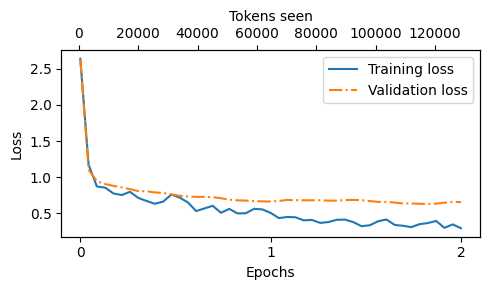

In [ ]:
#from previous_chapters import plot_losses
# Alternatively:
# from llms_from_scratch.ch05 import plot_losses        

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

- The loss decreases sharply at the beginning of the first epoch, which means the model starts learning quickly
- We can see that slight overfitting sets in at around 1 training epoch

&nbsp;
## Extracting and saving responses

- In this section, we save the test set responses for scoring in the next section
- We also save a copy of the model for future use
- But first, let's take a brief look at the responses generated by the finetuned model

In [ ]:
torch.manual_seed(123)


for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
)

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

- Save the model in case we want to reuse it in the future

In [ ]:
import re


file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

# Load model via
# model.load_state_dict(torch.load("gpt2-medium355M-sft.pth"))

Model saved as gpt2-medium355M-sft.pth


&nbsp;
## Evaluating the finetuned LLM
Work in progress